# Анализ датасета DRAGON для DeReC

Исследуем распределение длин текстов и оценим, сколько примеров обрезается при `max_length=512` токенов ruDeberta.

In [2]:
!python --version

Python 3.12.12


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [6]:
HF_DATASET_REPO = "Makson4ic/dragon-derec-dataset"
TOKENIZER_NAME = "deepvk/deberta-v1-base"
MAX_LENGTH = 512

ds = load_dataset(HF_DATASET_REPO)
tok = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

for split in ds:
    print(f"{split}: {len(ds[split])} examples")

README.md:   0%|          | 0.00/721 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.25M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.00M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12600 [00:00<?, ? examples/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

train: 12600 examples
val: 2700 examples
test: 2700 examples


## 1. Обзор датасета

In [7]:
# Собираем все сплиты в один DataFrame
rows = []
for split_name in ["train", "val", "test"]:
    for item in ds[split_name]:
        rows.append({**item, "split": split_name})

df = pd.DataFrame(rows)
print(f"Всего примеров: {len(df)}")
print(f"\nКолонки: {list(df.columns)}")
print(f"\nБаланс классов по сплитам:")
df.groupby(["split", "is_grounded"]).size().unstack(fill_value=0)

Всего примеров: 18000

Колонки: ['question_id', 'question', 'reference_answer', 'model_answer', 'found_ids', 'evidence_texts', 'is_grounded', 'split']

Баланс классов по сплитам:


is_grounded,False,True
split,,
test,1350,1350
train,6300,6300
val,1350,1350


In [8]:
# Формируем текстовые поля как в DeReC pipeline
df["claim"] = "question: " + df["question"] + "\nanswer: " + df["model_answer"]
df["evidence"] = df["evidence_texts"].apply(lambda texts: "\n".join(texts))
df["answer"] = df["model_answer"]
df["model_input"] = "claim: " + df["claim"] + " [SEP] evidence: " + df["evidence"]

# Длины в символах
df["claim_chars"] = df["claim"].str.len()
df["evidence_chars"] = df["evidence"].str.len()
df["answer_chars"] = df["answer"].str.len()
df["input_chars"] = df["model_input"].str.len()

# Длины в токенах
df["claim_tokens"] = df["claim"].apply(lambda x: len(tok.encode(x, add_special_tokens=False)))
df["evidence_tokens"] = df["evidence"].apply(lambda x: len(tok.encode(x, add_special_tokens=False)))
df["answer_tokens"] = df["answer"].apply(lambda x: len(tok.encode(x, add_special_tokens=False)))
df["input_tokens"] = df["model_input"].apply(lambda x: len(tok.encode(x, add_special_tokens=True)))

print("Готово: добавлены длины в символах и токенах")

Token indices sequence length is longer than the specified maximum sequence length for this model (1042 > 512). Running this sequence through the model will result in indexing errors


Готово: добавлены длины в символах и токенах


## 2. Длины текстов (символы)

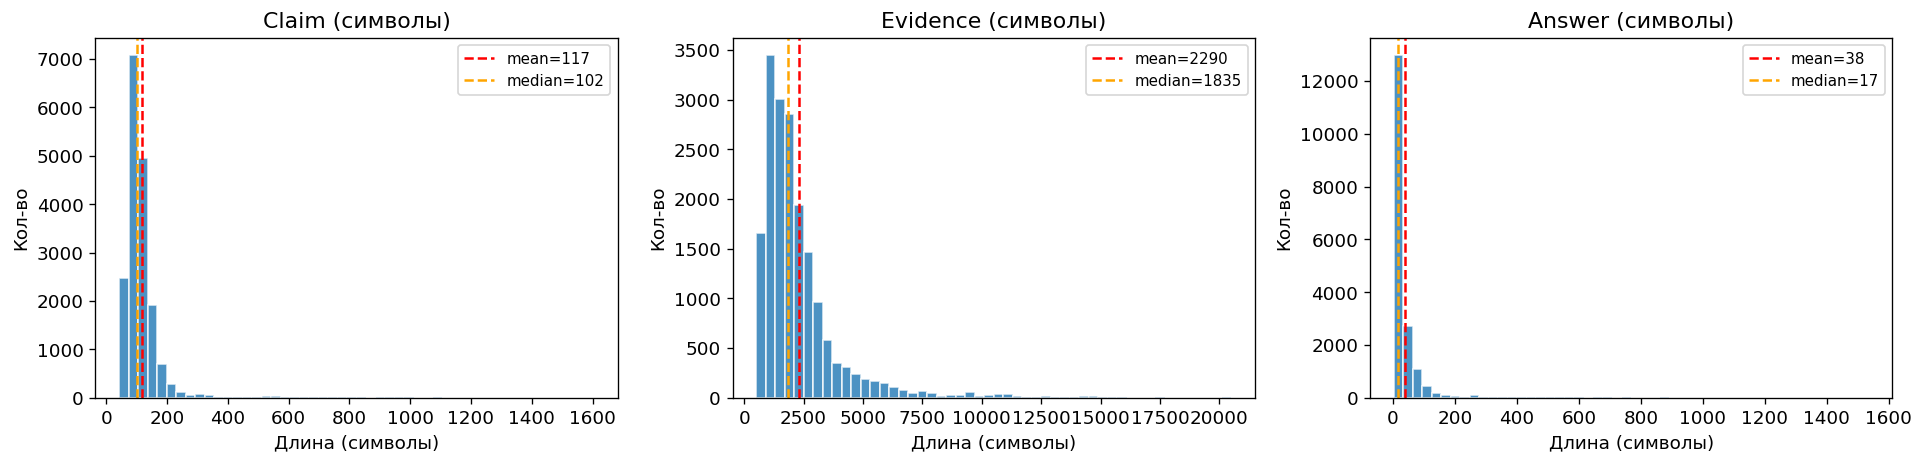

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes, ["claim_chars", "evidence_chars", "answer_chars"],
                                 ["Claim (символы)", "Evidence (символы)", "Answer (символы)"]):
    ax.hist(df[col], bins=50, edgecolor="white", alpha=0.8)
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"mean={df[col].mean():.0f}")
    ax.axvline(df[col].median(), color="orange", linestyle="--", label=f"median={df[col].median():.0f}")
    ax.set_title(title)
    ax.set_xlabel("Длина (символы)")
    ax.set_ylabel("Кол-во")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

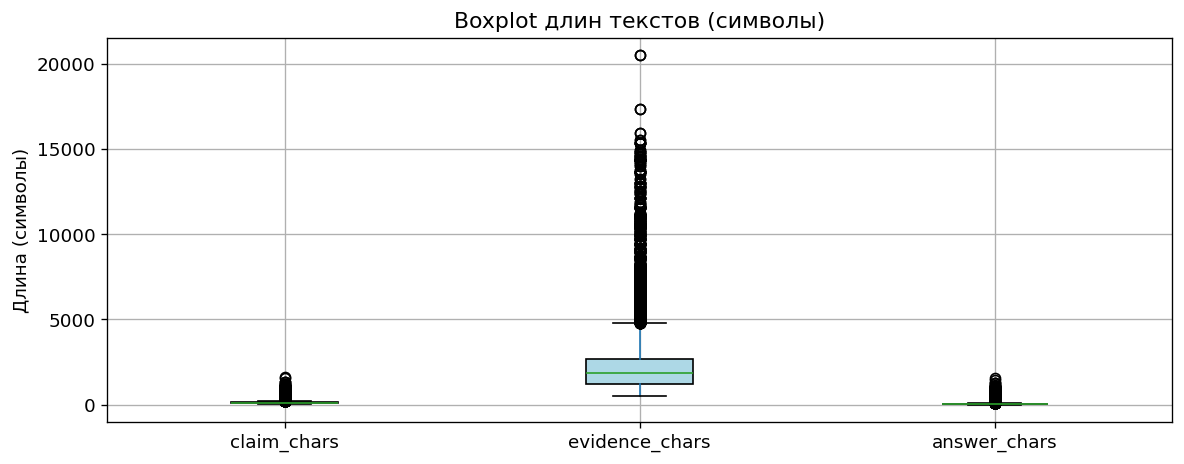

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
bp = df[["claim_chars", "evidence_chars", "answer_chars"]].boxplot(
    ax=ax, vert=True, patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
)
ax.set_ylabel("Длина (символы)")
ax.set_title("Boxplot длин текстов (символы)")
plt.tight_layout()
plt.show()

## 3. Длины текстов (токены ruDeberta)

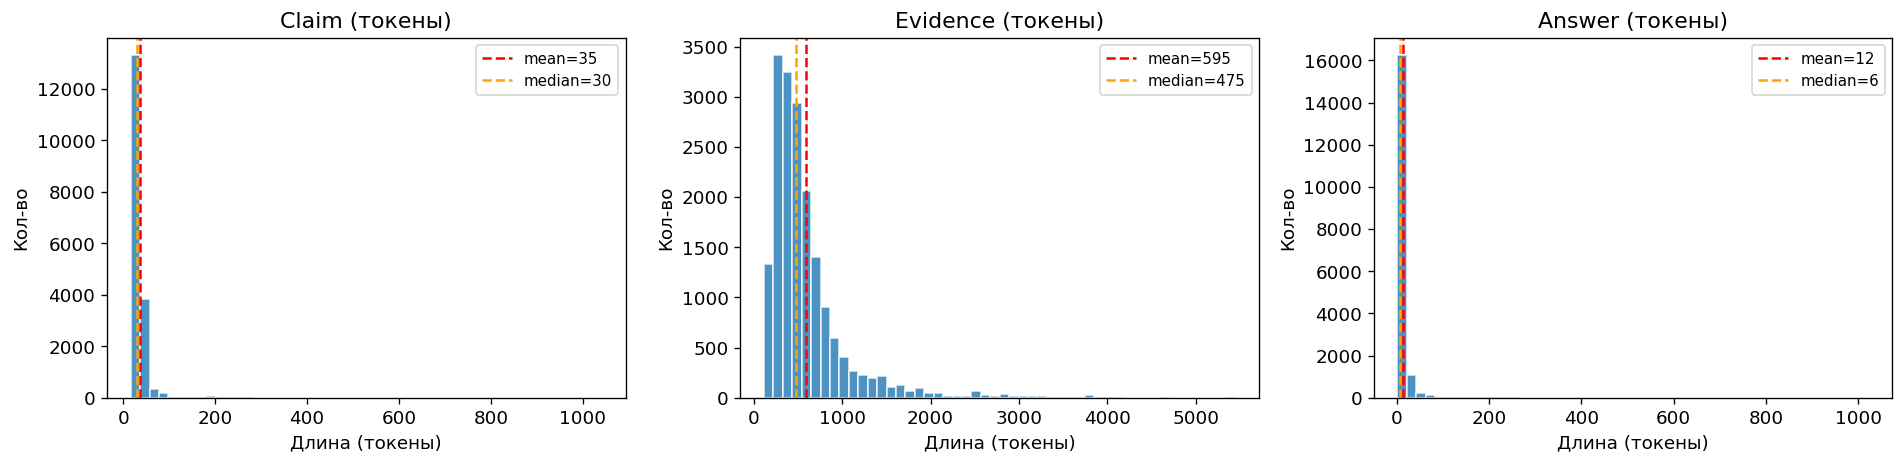

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(axes, ["claim_tokens", "evidence_tokens", "answer_tokens"],
                                 ["Claim (токены)", "Evidence (токены)", "Answer (токены)"]):
    ax.hist(df[col], bins=50, edgecolor="white", alpha=0.8)
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"mean={df[col].mean():.0f}")
    ax.axvline(df[col].median(), color="orange", linestyle="--", label=f"median={df[col].median():.0f}")
    ax.set_title(title)
    ax.set_xlabel("Длина (токены)")
    ax.set_ylabel("Кол-во")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

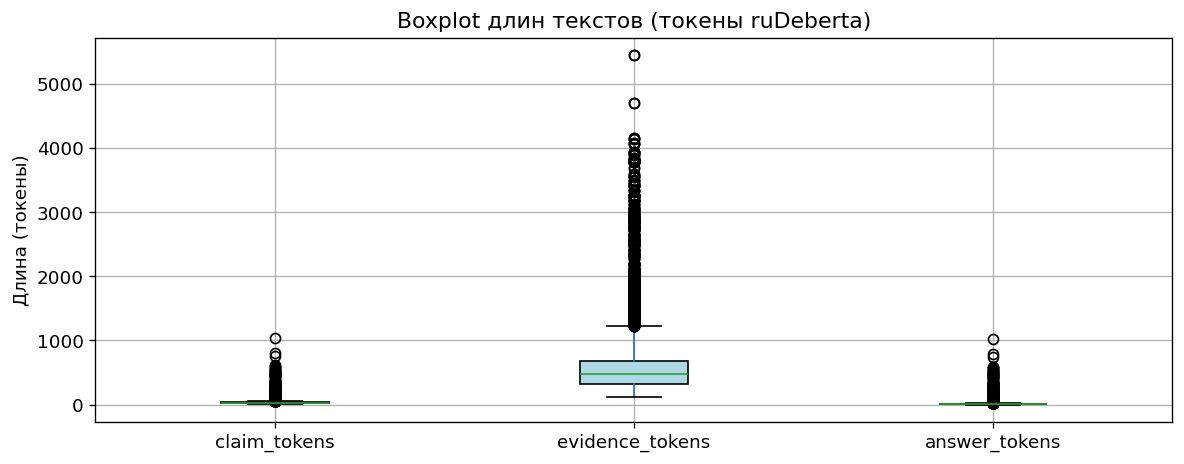

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
df[["claim_tokens", "evidence_tokens", "answer_tokens"]].boxplot(
    ax=ax, vert=True, patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
)
ax.set_ylabel("Длина (токены)")
ax.set_title("Boxplot длин текстов (токены ruDeberta)")
plt.tight_layout()
plt.show()

## 4. Анализ объединённого входа модели

Формат: `claim: {claim} [SEP] evidence: {evidence}` → токенизация с `add_special_tokens=True` → `max_length=512`

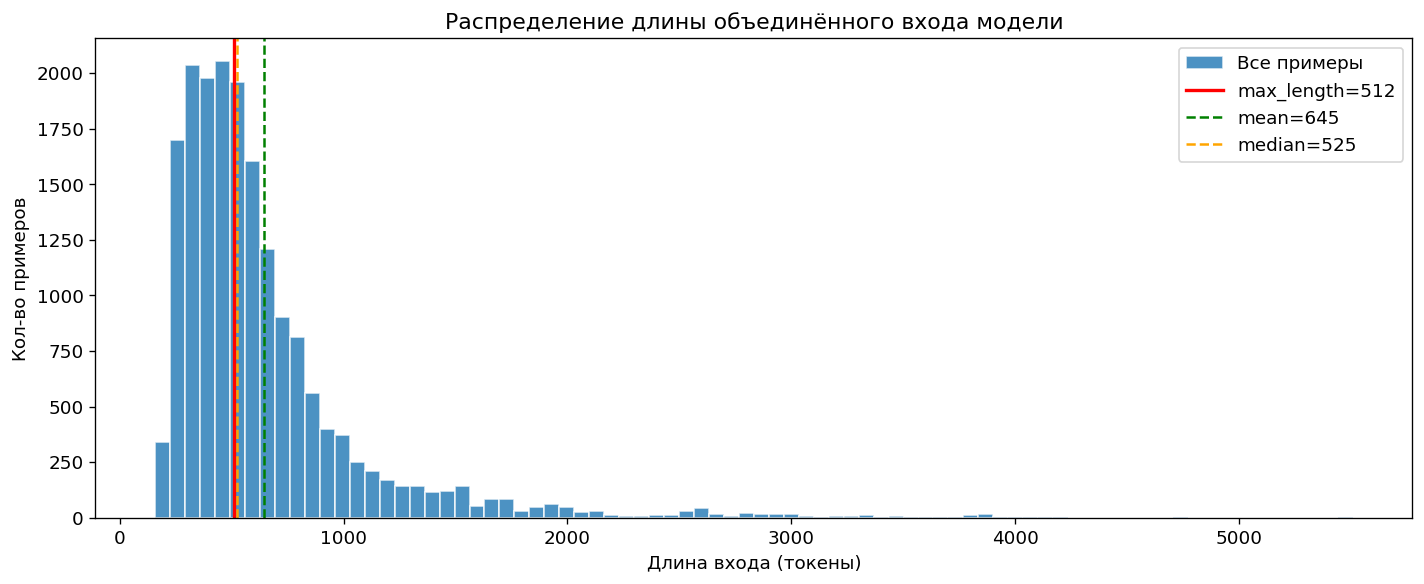

Обрезается: 9387 из 18000 примеров (52.1%)


In [37]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["input_tokens"], bins=80, edgecolor="white", alpha=0.8, label="Все примеры")
ax.axvline(MAX_LENGTH, color="red", linewidth=2, linestyle="-", label=f"max_length={MAX_LENGTH}")
ax.axvline(df["input_tokens"].mean(), color="green", linestyle="--", label=f"mean={df['input_tokens'].mean():.0f}")
ax.axvline(df["input_tokens"].median(), color="orange", linestyle="--", label=f"median={df['input_tokens'].median():.0f}")

ax.set_xlabel("Длина входа (токены)")
ax.set_ylabel("Кол-во примеров")
ax.set_title("Распределение длины объединённого входа модели")
ax.legend()
plt.tight_layout()
plt.show()

n_truncated = (df["input_tokens"] > MAX_LENGTH).sum()
pct_truncated = n_truncated / len(df) * 100
print(f"Обрезается: {n_truncated} из {len(df)} примеров ({pct_truncated:.1f}%)")

In [38]:
# Распределение по классам: различается ли truncation?
for label, name in [(True, "grounded"), (False, "ungrounded")]:
    subset = df[df["is_grounded"] == label]
    n_trunc = (subset["input_tokens"] > MAX_LENGTH).sum()
    pct = n_trunc / len(subset) * 100
    print(f"{name}: {n_trunc}/{len(subset)} обрезается ({pct:.1f}%), mean={subset['input_tokens'].mean():.0f} токенов")

grounded: 4640/9000 обрезается (51.6%), mean=643 токенов
ungrounded: 4747/9000 обрезается (52.7%), mean=648 токенов


## 5. Анализ обрезки

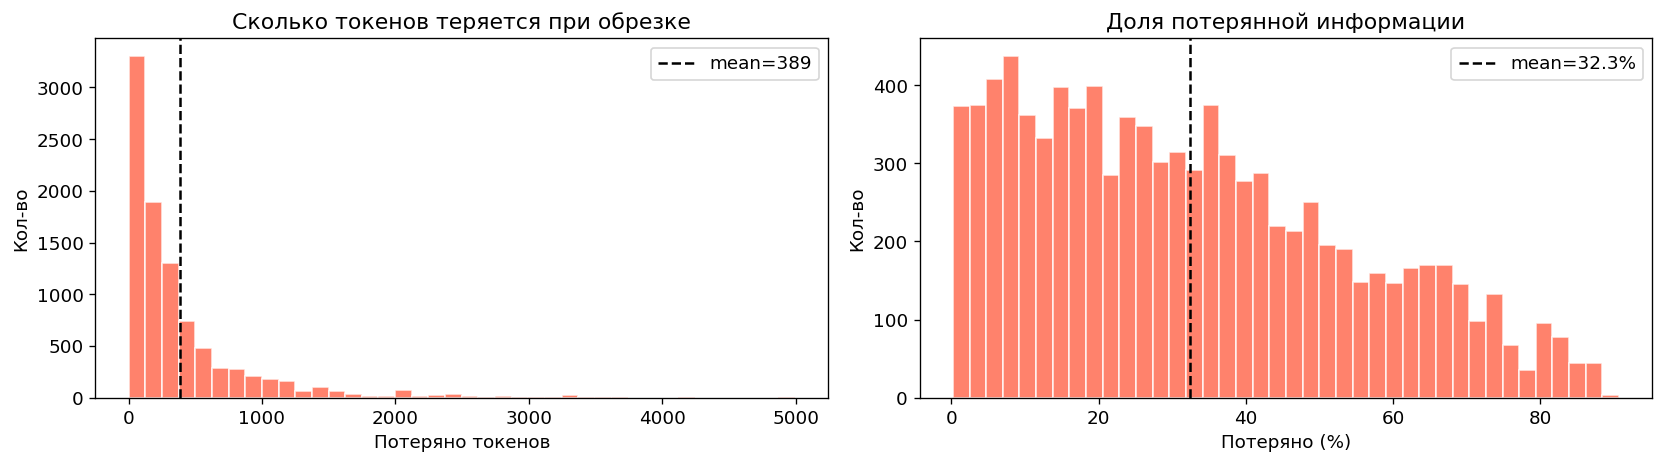


Среди обрезанных (9387 примеров):
  Потеряно токенов: mean=389, median=210, max=4994
  Доля потери: mean=32.3%, max=90.7%


In [39]:
df["tokens_lost"] = (df["input_tokens"] - MAX_LENGTH).clip(lower=0)
truncated = df[df["tokens_lost"] > 0].copy()

if len(truncated) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Гистограмма потерянных токенов
    axes[0].hist(truncated["tokens_lost"], bins=40, edgecolor="white", alpha=0.8, color="tomato")
    axes[0].axvline(truncated["tokens_lost"].mean(), color="black", linestyle="--",
                    label=f"mean={truncated['tokens_lost'].mean():.0f}")
    axes[0].set_xlabel("Потеряно токенов")
    axes[0].set_ylabel("Кол-во")
    axes[0].set_title("Сколько токенов теряется при обрезке")
    axes[0].legend()

    # Доля потерянной информации
    truncated["pct_lost"] = truncated["tokens_lost"] / truncated["input_tokens"] * 100
    axes[1].hist(truncated["pct_lost"], bins=40, edgecolor="white", alpha=0.8, color="tomato")
    axes[1].axvline(truncated["pct_lost"].mean(), color="black", linestyle="--",
                    label=f"mean={truncated['pct_lost'].mean():.1f}%")
    axes[1].set_xlabel("Потеряно (%)")
    axes[1].set_ylabel("Кол-во")
    axes[1].set_title("Доля потерянной информации")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"\nСреди обрезанных ({len(truncated)} примеров):")
    print(f"  Потеряно токенов: mean={truncated['tokens_lost'].mean():.0f}, "
          f"median={truncated['tokens_lost'].median():.0f}, "
          f"max={truncated['tokens_lost'].max():.0f}")
    print(f"  Доля потери: mean={truncated['pct_lost'].mean():.1f}%, "
          f"max={truncated['pct_lost'].max():.1f}%")
else:
    print("Ни один пример не обрезается!")

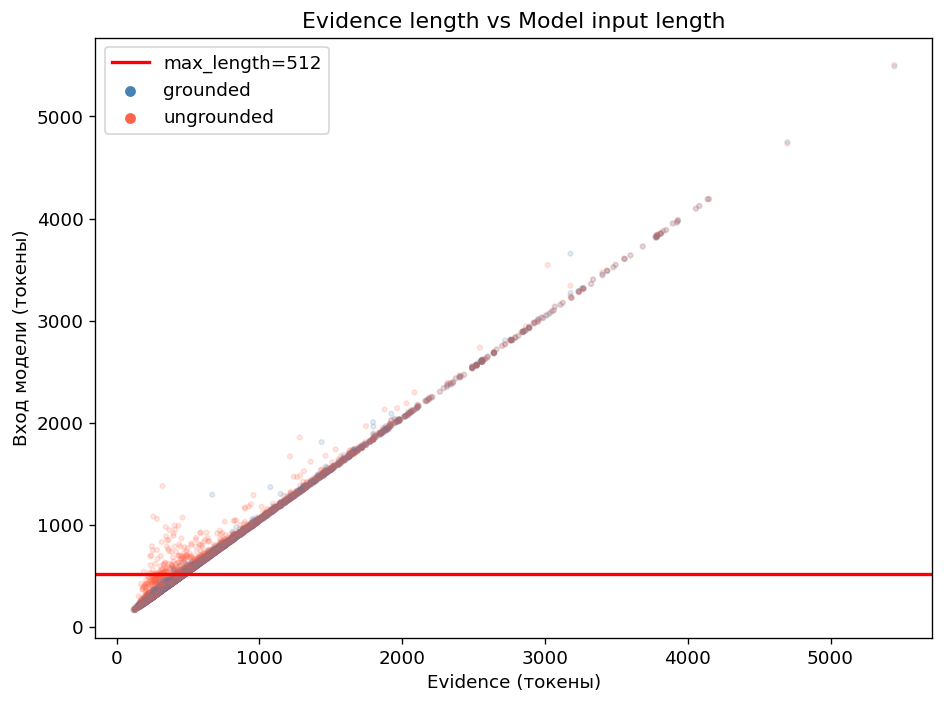

In [40]:
# Scatter: длина входа vs длина evidence (основной источник длины)
fig, ax = plt.subplots(figsize=(8, 6))

colors = df["is_grounded"].map({True: "steelblue", False: "tomato"})
ax.scatter(df["evidence_tokens"], df["input_tokens"], c=colors, alpha=0.15, s=8)
ax.axhline(MAX_LENGTH, color="red", linewidth=2, label=f"max_length={MAX_LENGTH}")

# Легенда для классов
ax.scatter([], [], c="steelblue", label="grounded", s=30)
ax.scatter([], [], c="tomato", label="ungrounded", s=30)

ax.set_xlabel("Evidence (токены)")
ax.set_ylabel("Вход модели (токены)")
ax.set_title("Evidence length vs Model input length")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Сводная таблица

In [41]:
stats_cols = ["claim_tokens", "evidence_tokens", "answer_tokens", "input_tokens",
              "claim_chars", "evidence_chars", "answer_chars", "input_chars"]

summary = df[stats_cols].agg(["mean", "median", "min", "max",
                               lambda x: np.percentile(x, 95),
                               lambda x: np.percentile(x, 99)]).round(1)
summary.index = ["mean", "median", "min", "max", "p95", "p99"]

summary

,claim_tokens,evidence_tokens,answer_tokens,input_tokens,claim_chars,evidence_chars,answer_chars,input_chars
mean,35.3,595.3,12.4,645.3,117.3,2290.1,38.2,2431.5
median,30.0,475.0,6.0,525.0,102.0,1835.0,17.0,1984.0
min,16.0,118.0,1.0,159.0,42.0,513.0,2.0,613.0
max,1042.0,5447.0,1023.0,5506.0,1605.0,20503.0,1535.0,20692.0
p95,56.0,1455.0,32.0,1507.0,196.0,5569.0,111.0,5672.1
p99,170.0,2643.0,148.0,2687.0,535.0,10437.2,473.0,10573.1


In [42]:
# Сводка по сплитам
split_summary = df.groupby("split")["input_tokens"].agg(
    ["mean", "median", "min", "max",
     lambda x: np.percentile(x, 95),
     lambda x: (x > MAX_LENGTH).sum(),
     lambda x: (x > MAX_LENGTH).mean() * 100]
).round(1)
split_summary.columns = ["mean", "median", "min", "max", "p95", "n_truncated", "pct_truncated"]

split_summary

,mean,median,min,max,p95,n_truncated,pct_truncated
split,,,,,,,
test,628.8,523.0,166,3844,1378.1,1400,51.9
train,647.2,524.0,159,5506,1523.0,6549,52.0
val,653.0,530.0,162,4191,1496.0,1438,53.3
